# Turtle Movement Simulation and Patrol-Route Optimization

## Project Context

This notebook reconstructs the movement and ant-colony optimization ideas from the team project as a reproducible methodological demonstration. No real turtle tracking, RFID, patrol, or seizure-location data were supplied, so every coordinate in this notebook is explicitly synthetic.

## Research Question

How can a synthetic seasonal movement model be converted into candidate monitoring nodes and an illustrative closed route using ant-colony optimization?

In [1]:
from pathlib import Path
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans

RANDOM_SEED = 2024
N_TURTLES = 12
N_STEPS = 40
N_MONITORING_NODES = 8
N_ANTS = 30
N_ITERATIONS = 120
MAP_SIZE = 100.0

sns.set_theme(style="whitegrid", context="notebook")
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Data

The dataset below is generated inside the notebook. Seasonal centers and random-walk parameters are modeling assumptions chosen for demonstration; they are not fitted to observed turtle behavior.

In [2]:
SEASON_CONFIG = {
    "Spring": {"center": (35.0, 62.0), "phase": 0.0},
    "Summer": {"center": (68.0, 72.0), "phase": 0.8},
    "Autumn": {"center": (64.0, 35.0), "phase": 1.6},
    "Winter": {"center": (30.0, 28.0), "phase": 2.4},
}

def simulate_seasonal_positions(season, center, phase, seed):
    # Generate bounded synthetic tracks attracted to a seasonal center.
    rng = np.random.default_rng(seed)
    records = []
    center = np.asarray(center, dtype=float)
    for turtle_id in range(N_TURTLES):
        position = center + rng.normal(0, 9, size=2)
        for step in range(N_STEPS):
            attraction = 0.10 * (center - position)
            cycle = 0.6 * np.array([
                np.cos(2 * np.pi * step / N_STEPS + phase),
                np.sin(2 * np.pi * step / N_STEPS + phase),
            ])
            position = np.clip(position + attraction + cycle + rng.normal(0, 2.4, size=2), 0, MAP_SIZE)
            records.append(
                {"season": season, "turtle_id": turtle_id, "step": step, "x": position[0], "y": position[1]}
            )
    return pd.DataFrame(records)

tracks = pd.concat(
    [
        simulate_seasonal_positions(season, values["center"], values["phase"], RANDOM_SEED + index)
        for index, (season, values) in enumerate(SEASON_CONFIG.items())
    ],
    ignore_index=True,
)
print(f"Synthetic observations: {len(tracks):,}")
print(f"Synthetic individuals per season: {tracks.groupby('season')['turtle_id'].nunique().to_dict()}")
display(tracks.head())

Synthetic observations: 1,920
Synthetic individuals per season: {'Autumn': 12, 'Spring': 12, 'Summer': 12, 'Winter': 12}


,season,turtle_id,step,x,y
0,Spring,0,0,46.685868,72.963921
1,Spring,0,1,42.767174,72.122661
2,Spring,0,2,44.628332,72.517854
3,Spring,0,3,48.544788,73.540487
4,Spring,0,4,49.211143,70.983935


## Methods: Movement Simulation

Each synthetic agent follows a bounded random walk with weak attraction toward a season-specific center and a small cyclic component. The fixed random seed makes the demonstration reproducible.

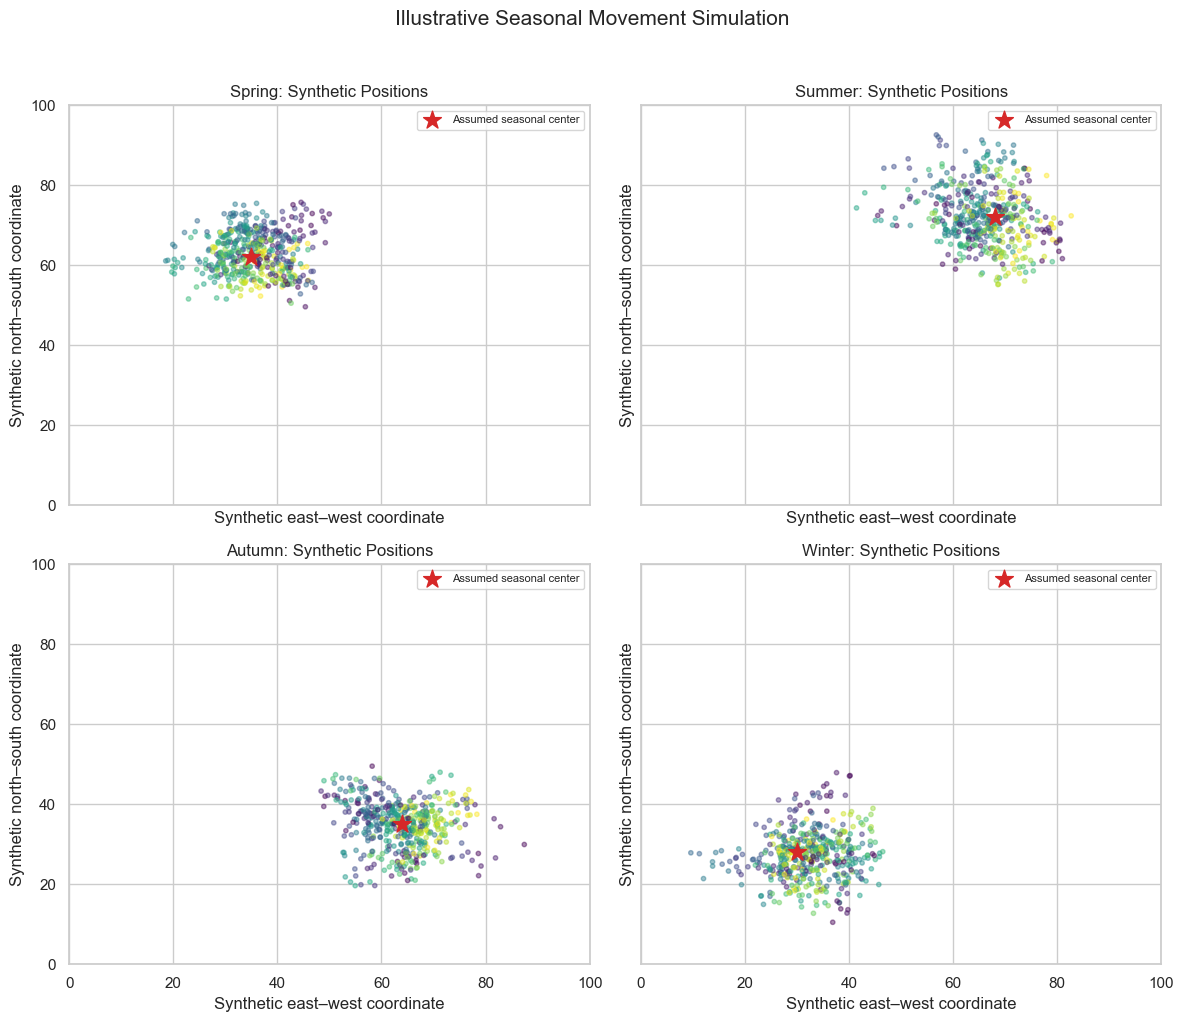

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, season in zip(axes.flat, SEASON_CONFIG):
    subset = tracks.loc[tracks["season"].eq(season)]
    ax.scatter(subset["x"], subset["y"], c=subset["step"], cmap="viridis", s=10, alpha=0.45)
    ax.scatter(*SEASON_CONFIG[season]["center"], marker="*", s=180, color="#d62828", label="Assumed seasonal center")
    ax.set_title(f"{season}: Synthetic Positions")
    ax.set_xlabel("Synthetic east–west coordinate")
    ax.set_ylabel("Synthetic north–south coordinate")
    ax.set_xlim(0, MAP_SIZE)
    ax.set_ylim(0, MAP_SIZE)
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Illustrative Seasonal Movement Simulation", y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_synthetic_seasonal_movement.png", dpi=180, bbox_inches="tight")
plt.show()

## Methods: Monitoring Nodes and Route Optimization

K-means clustering converts the synthetic positions into eight candidate monitoring nodes per season. Ant-colony optimization then searches for a short closed route through those nodes. The objective is Euclidean distance in an abstract coordinate system. Inputs, outputs, and assumptions are therefore computational rather than operational.

In [4]:
def route_length(route, distance_matrix):
    # Return the length of a closed route.
    return float(sum(distance_matrix[route[i], route[(i + 1) % len(route)]] for i in range(len(route))))

def ant_colony_route(points, seed, n_ants=N_ANTS, n_iterations=N_ITERATIONS, alpha=1.0, beta=3.0, evaporation=0.35):
    # Search for a short closed route through 2D points.
    rng = np.random.default_rng(seed)
    differences = points[:, None, :] - points[None, :, :]
    distances = np.sqrt(np.sum(differences**2, axis=2))
    np.fill_diagonal(distances, np.inf)
    pheromone = np.ones_like(distances)
    np.fill_diagonal(pheromone, 0.0)
    best_route, best_length = None, np.inf

    for _ in range(n_iterations):
        candidate_routes = []
        for _ in range(n_ants):
            start = int(rng.integers(len(points)))
            route = [start]
            unvisited = set(range(len(points))) - {start}
            while unvisited:
                options = np.array(sorted(unvisited))
                desirability = (
                    pheromone[route[-1], options] ** alpha
                    * (1.0 / distances[route[-1], options]) ** beta
                )
                probabilities = desirability / desirability.sum()
                next_node = int(rng.choice(options, p=probabilities))
                route.append(next_node)
                unvisited.remove(next_node)
            length = route_length(route, distances)
            candidate_routes.append((route, length))
            if length < best_length:
                best_route, best_length = route.copy(), length

        pheromone *= 1.0 - evaporation
        for route, length in candidate_routes:
            deposit = 1.0 / length
            for index in range(len(route)):
                left, right = route[index], route[(index + 1) % len(route)]
                pheromone[left, right] += deposit
                pheromone[right, left] += deposit

    return np.asarray(best_route, dtype=int), float(best_length), distances

node_frames = []
route_results = {}
for season_index, season in enumerate(SEASON_CONFIG):
    season_points = tracks.loc[tracks["season"].eq(season), ["x", "y"]]
    clusterer = KMeans(n_clusters=N_MONITORING_NODES, random_state=RANDOM_SEED, n_init=20)
    clusterer.fit(season_points)
    nodes = clusterer.cluster_centers_
    route, optimized_length, distances = ant_colony_route(nodes, seed=RANDOM_SEED + 100 + season_index)
    baseline_route = np.arange(N_MONITORING_NODES)
    baseline_length = route_length(baseline_route, distances)
    route_results[season] = {
        "nodes": nodes,
        "route": route,
        "optimized_length": optimized_length,
        "index_order_length": baseline_length,
    }
    node_frames.append(
        pd.DataFrame(nodes, columns=["x", "y"]).assign(season=season, node=np.arange(N_MONITORING_NODES))
    )

route_summary = pd.DataFrame(
    [
        {
            "season": season,
            "optimized_route_length": values["optimized_length"],
            "index_order_benchmark": values["index_order_length"],
            "difference_from_benchmark_pct": 100 * (values["index_order_length"] - values["optimized_length"]) / values["index_order_length"],
        }
        for season, values in route_results.items()
    ]
)
display(route_summary.round(2))

,season,optimized_route_length,index_order_benchmark,difference_from_benchmark_pct
0,Spring,63.49,97.11,34.63
1,Summer,82.65,116.52,29.07
2,Autumn,78.22,119.37,34.47
3,Winter,74.38,105.98,29.82


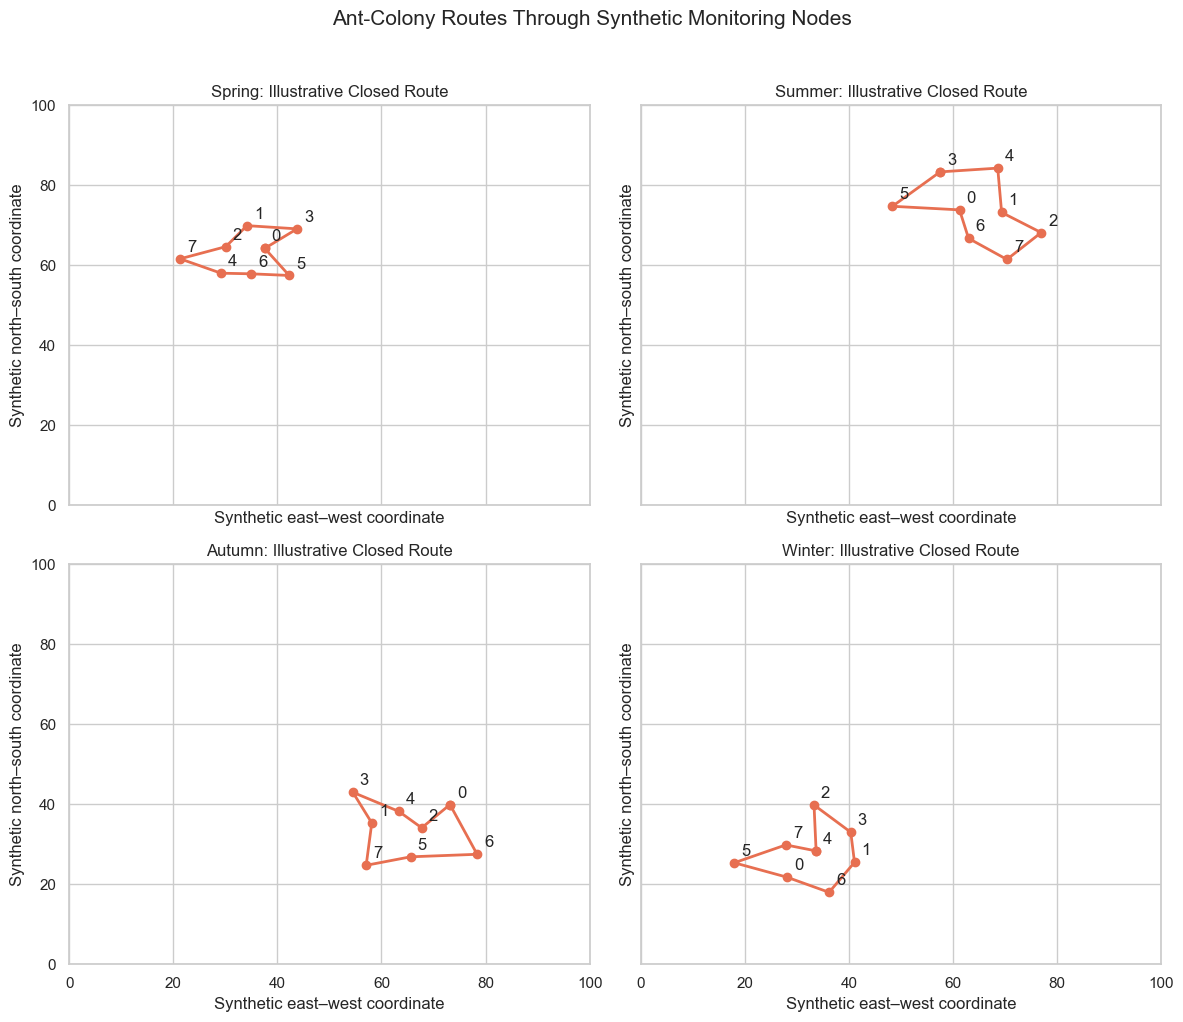

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, season in zip(axes.flat, SEASON_CONFIG):
    values = route_results[season]
    nodes = values["nodes"]
    route = values["route"]
    closed_route = np.append(route, route[0])
    ax.plot(nodes[closed_route, 0], nodes[closed_route, 1], marker="o", linewidth=2, color="#e76f51")
    for node_id, (x, y) in enumerate(nodes):
        ax.annotate(str(node_id), (x, y), xytext=(5, 5), textcoords="offset points")
    ax.set_title(f"{season}: Illustrative Closed Route")
    ax.set_xlabel("Synthetic east–west coordinate")
    ax.set_ylabel("Synthetic north–south coordinate")
    ax.set_xlim(0, MAP_SIZE)
    ax.set_ylim(0, MAP_SIZE)
fig.suptitle("Ant-Colony Routes Through Synthetic Monitoring Nodes", y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_synthetic_patrol_routes.png", dpi=180, bbox_inches="tight")
plt.show()

## Results

The executed route table reports the optimized distance and a simple index-order benchmark for each season. The benchmark is only a computational reference; it is not an existing patrol route. The figures show that the workflow is reproducible with fixed seeds.

## Limitations

- Every location is synthetic and cannot be interpreted as a real turtle habitat or trade hotspot.
- Euclidean distance omits coastlines, terrain, vessel constraints, time windows, risk, cost, and legal or ecological requirements.
- K-means centers are modeling artifacts, not validated RFID-reader or patrol locations.
- Ant-colony optimization is heuristic and does not guarantee the global optimum.
- No field observations were available for calibration or external validation.

## Takeaways

The notebook provides a clean example of how movement simulation, clustering, and route optimization can be connected. Real-world use would require validated tracking data, a defensible objective function, operational constraints, stakeholder review, and prospective evaluation.